In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    StandardScaler,
    Normalizer,
    FunctionTransformer,
    PowerTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    SplineTransformer,
)
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_extraction import FeatureHasher
from sklearn.compose import make_column_transformer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split, cross_val_score


In [2]:
# Revisit the OKCupid data
df = pd.read_csv("../04_categorical/profiles_revised.csv")

In [3]:
# Target: predict if job is stem related
df["job"].value_counts()
df["stem_job"] = df["job"].str.contains("computer|science", case=False, na=False)
df["stem_job"].value_counts() / len(df)

stem_job
False    0.840573
True     0.159427
Name: count, dtype: float64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   body_type    54650 non-null  object 
 2   diet         35551 non-null  object 
 3   drinks       56961 non-null  object 
 4   drugs        45866 non-null  object 
 5   education    53318 non-null  object 
 6   ethnicity    54266 non-null  object 
 7   height       59943 non-null  float64
 8   income       59946 non-null  int64  
 9   job          51748 non-null  object 
 10  offspring    24385 non-null  object 
 11  orientation  59946 non-null  object 
 12  pets         40025 non-null  object 
 13  religion     39720 non-null  object 
 14  sex          59946 non-null  object 
 15  sign         48890 non-null  object 
 16  smokes       54434 non-null  object 
 17  speaks       59896 non-null  object 
 18  status       59946 non-null  object 
 19  stem

## Understanding missing values
In addition to looking at how many of which feature are missing, it's useful to understand whether missing values tend to co-occur.

In [11]:
print("Missing values by percentage of dataset")
df.isna().sum().sort_values(ascending=False) / len(df) * 100

Missing values by percentage of dataset


offspring      59.321723
diet           40.694959
religion       33.740366
pets           33.231575
drugs          23.487806
sign           18.443266
job            13.675641
education      11.056618
ethnicity       9.475194
smokes          9.194942
body_type       8.834618
drinks          4.979482
speaks          0.083408
height          0.005005
age             0.000000
income          0.000000
orientation     0.000000
sex             0.000000
status          0.000000
stem_job        0.000000
dtype: float64

Text(0, 0.5, 'Number of samples')

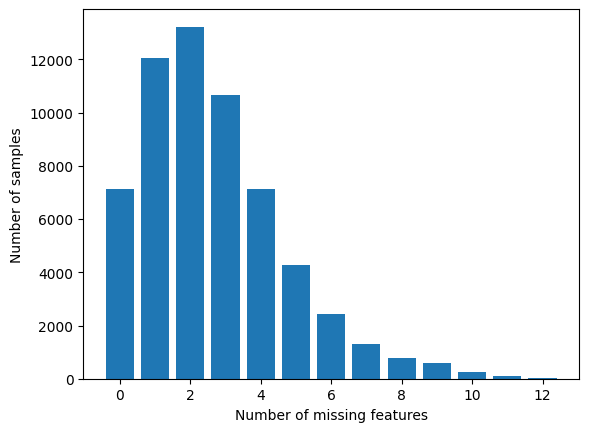

In [17]:
# How many missing values per sample?
missing_per_sample = df.isna().sum(axis=1).value_counts()
plt.bar(missing_per_sample.index, missing_per_sample)
plt.xlabel("Number of missing features")
plt.ylabel("Number of samples")

<Axes: >

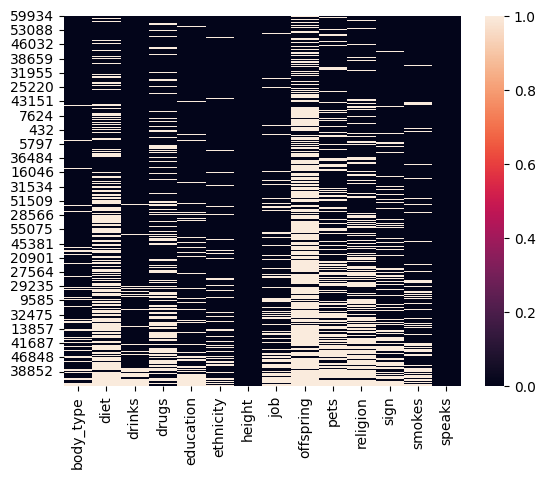

In [34]:
# Maybe a heatmap can show trends?
missing_order = df.isna().sum(axis=1).sort_values()
missing_order.drop(missing_order[missing_order == 0].index, inplace=True)
sns.heatmap(df.loc[missing_order.index].isna())

<Axes: >

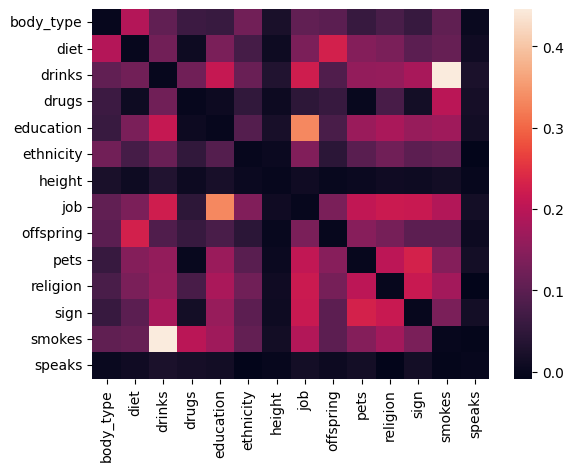

In [37]:
# how about correlations between missing values?
missing_cor = df.isna().corr()
# zero out the diagonal so we can visualize it better
missing_cor -= np.identity(missing_cor.shape[0])
sns.heatmap(missing_cor)

In [ ]:
# select features to use in the model
numeric_features = ["age", "height", "income"]
cat_features = ["drinks", "education", "sex"]

# df.dropna(subset=numeric_features + cat_features, inplace=True)

X = df[numeric_features + cat_features].copy()
y = df["stem_job"].copy()

# split!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=df["stem_job"], random_state=12345
)

# print percentage in each class to double check stratification
print(y_train.value_counts() / len(y_train))
print(y_test.value_counts() / len(y_test))

In [ ]:
# Define the trickier encoders
drink_enc = OrdinalEncoder(
            categories=[
                [
                    "not at all",
                    "rarely",
                    "socially",
                    "often",
                    "very often",
                    "desperately",
                ]
            ],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        )

# This took a while mucking around to figure out the right magic between df/series
def split_edu(df):
    df["education"] = df["education"].str.split(" ")
    return df["education"]

edu_enc = make_pipeline(
        FunctionTransformer(split_edu, validate=False),
        FeatureHasher(n_features=8, input_type="string"),
    )


In [ ]:
df["education"].str.split(" ")

In [ ]:
# Build the preprocessing pipeline

numeric_pipeline = make_pipeline(
    SimpleImputer(strategy="mean", add_indicator=True),
    PowerTransformer(method="yeo-johnson"),
)

preprocessor = make_column_transformer(
    (PowerTransformer(method="yeo-johnson"), numeric_features),
    (OneHotEncoder(handle_unknown="ignore"), ["sex"]), # sparse_output = False for pandas output
    (drink_enc, ["drinks"]),
    (edu_enc, ["education"]), # can't be converted to pandas
    
)#.set_output(transform="pandas")
preprocessor

In [ ]:
type(X_train)

In [ ]:
preprocessor.fit_transform(X_train, y_train)

In [ ]:
# Now add on a model!
pipeline = make_pipeline(
    preprocessor,
    SGDClassifier(class_weight="balanced"), #class_weight="balanced" does some magic
)

cross_val_score(pipeline, X_train, y_train, scoring="recall")